# Обработчики для эксперимента: паспорт строительного объекта

## 0. Установка зависимостей

In [ ]:
!apt-get update -qq
!apt-get install -y -qq tesseract-ocr tesseract-ocr-rus poppler-utils
!pip install -q pandas openpyxl python-docx pymupdf pytesseract pillow matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package poppler-utils.
(Reading database ... 122402 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Selecting previously unselected package tesseract-ocr-rus.
Preparing to unpack .../tesseract-ocr-rus_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-rus (1:4.00~git30-7274cfa-1.1) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up tesseract-ocr-rus (1:4.00~git30-7274cfa-1.1) ...
Processing triggers for man-db (2.10.2-1) ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 70.4 MB/s eta 0:00:00


## 1. Импорты и настройки путей

In [ ]:
from pathlib import Path
import os
import re
import json
import time
import math
import zipfile
from typing import Dict, List, Any, Optional, Tuple

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/content')
GROUND_TRUTH_PATH = PROJECT_ROOT / 'ground_truth.csv'
MANIFEST_PATH = PROJECT_ROOT / 'manifest.csv'

DATA_DIR = PROJECT_ROOT / 'data'
INTERMEDIATE_DIR = PROJECT_ROOT / 'intermediate'
TEXTS_DIR = INTERMEDIATE_DIR / 'texts'
RESULTS_DIR = PROJECT_ROOT / 'results'

TEXTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_FIELDS = [
    'passport_id',
    'object_name',
    'object_type',
    'address',
    'cadastral_number',
    'commissioning_year',
    'total_area_m2',
    'floors_count',
    'structural_material',
    'technical_condition',
]

print('PROJECT_ROOT:', PROJECT_ROOT)
print('TEXTS_DIR:', TEXTS_DIR)
print('RESULTS_DIR:', RESULTS_DIR)

PROJECT_ROOT: /content
TEXTS_DIR: /content/intermediate/texts
RESULTS_DIR: /content/results


## 2. Загрузка файлов в Colab

`ground_truth.csv`, `manifest.csv` и папку `data` в `/content`.

In [ ]:
!unzip data.zip

Archive:  data.zip
   creating: data/
  inflating: data/.DS_Store          
  inflating: __MACOSX/data/._.DS_Store  
  inflating: data/ground_truth.csv   
  inflating: __MACOSX/data/._ground_truth.csv  
   creating: data/xlsx/
   creating: data/pdf/
   creating: data/png/
  inflating: data/manifest.csv       
  inflating: __MACOSX/data/._manifest.csv  
   creating: data/docx/
  inflating: data/xlsx/R002.xlsx     
  inflating: __MACOSX/data/xlsx/._R002.xlsx  
  inflating: data/xlsx/R014.xlsx     
  inflating: __MACOSX/data/xlsx/._R014.xlsx  
  inflating: data/xlsx/R015.xlsx     
  inflating: __MACOSX/data/xlsx/._R015.xlsx  
  inflating: data/xlsx/R003.xlsx     
  inflating: __MACOSX/data/xlsx/._R003.xlsx  
  inflating: data/xlsx/R004.xlsx     
  inflating: __MACOSX/data/xlsx/._R004.xlsx  
  inflating: data/xlsx/R012.xlsx     
  inflating: __MACOSX/data/xlsx/._R012.xlsx  
  inflating: data/xlsx/R008.xlsx     
  inflating: __MACOSX/data/xlsx/._R008.xlsx  
  inflating: data/xlsx/R009.xlsx 

## 3. Чтение `ground_truth.csv` и `manifest.csv`

In [ ]:
def read_csv_auto(path: Path) -> pd.DataFrame:
    """Читает CSV с автоопределением разделителя. Подходит для ; и ,."""
    if not path.exists():
        raise FileNotFoundError(f'Файл не найден: {path}')
    return pd.read_csv(path, sep=None, engine='python', dtype=str).fillna('')


ground_truth = read_csv_auto(GROUND_TRUTH_PATH)
manifest = read_csv_auto(MANIFEST_PATH)

print('ground_truth shape:', ground_truth.shape)
display(ground_truth.head())

print('manifest shape:', manifest.shape)
display(manifest.head(10))

missing_gt_cols = [c for c in ['record_id'] + TARGET_FIELDS if c not in ground_truth.columns]
missing_manifest_cols = [c for c in ['record_id', 'format', 'path'] if c not in manifest.columns]

if missing_gt_cols:
    raise ValueError(f'В ground_truth.csv отсутствуют колонки: {missing_gt_cols}')
if missing_manifest_cols:
    raise ValueError(f'В manifest.csv отсутствуют колонки: {missing_manifest_cols}')

ground_truth shape: (15, 11)


,record_id,passport_id,object_name,object_type,address,cadastral_number,commissioning_year,total_area_m2,floors_count,structural_material,technical_condition
0,R001,PBO-2026-001,Административное здание Северного участка,здание,"г. Москва, ул. Проектная, д. 14",77:01:0004012:128,2018,"3240,5",5,монолитный железобетон,работоспособное
1,R002,PBO-2026-002,Производственный корпус №2,здание,"г. Казань, Индустриальный пр-т, д. 7",16:50:070301:452,2012,"8750,0",3,сборный железобетон,ограниченно работоспособное
2,R003,PBO-2026-003,Склад готовой продукции,здание,"г. Екатеринбург, ул. Логистическая, д. 22",66:41:0502021:319,2020,"5120,3",1,металлокаркас,работоспособное
3,R004,PBO-2026-004,Подземная насосная станция,сооружение,"г. Новосибирск, ул. Водозаборная, стр. 5",54:35:012045:87,2009,"640,0",0,железобетон,исправное
4,R005,PBO-2026-005,Пешеходный мост через технологический проезд,сооружение,"г. Нижний Новгород, промзона Восточная, участок 3",52:18:0060210:604,2015,"1180,0",0,сталь,работоспособное


manifest shape: (60, 5)


,record_id,document_id,format,path,template_id
0,R001,R001,xlsx,data/xlsx/R001.xlsx,1
1,R002,R002,xlsx,data/xlsx/R002.xlsx,1
2,R003,R003,xlsx,data/xlsx/R003.xlsx,1
3,R004,R004,xlsx,data/xlsx/R004.xlsx,1
4,R005,R005,xlsx,data/xlsx/R005.xlsx,1
5,R006,R006,xlsx,data/xlsx/R006.xlsx,1
6,R007,R007,xlsx,data/xlsx/R007.xlsx,1
7,R008,R008,xlsx,data/xlsx/R008.xlsx,1
8,R009,R009,xlsx,data/xlsx/R009.xlsx,2
9,R010,R010,xlsx,data/xlsx/R010.xlsx,2


## 4. Извлечение текста из DOCX/XLSX/PDF/PNG

In [ ]:
def extract_docx_text(path: Path) -> str:
    from docx import Document

    doc = Document(str(path))
    parts = []

    for p in doc.paragraphs:
        text = p.text.strip()
        if text:
            parts.append(text)

    for table_idx, table in enumerate(doc.tables, start=1):
        parts.append(f'--- TABLE {table_idx} ---')
        for row in table.rows:
            cells = [cell.text.strip().replace('\n', ' ') for cell in row.cells]
            cells = [c for c in cells if c]
            if not cells:
                continue
            if len(cells) == 2:
                parts.append(f'{cells[0]}: {cells[1]}')
            else:
                parts.append(' | '.join(cells))

    return '\n'.join(parts)


def extract_xlsx_text(path: Path) -> str:
    from openpyxl import load_workbook

    wb = load_workbook(str(path), data_only=True)
    parts = []

    for sheet in wb.worksheets:
        parts.append(f'--- SHEET: {sheet.title} ---')
        for row in sheet.iter_rows(values_only=True):
            values = []
            for v in row:
                if v is None:
                    continue
                s = str(v).strip()
                if s:
                    values.append(s)
            if not values:
                continue
            if len(values) == 2:
                parts.append(f'{values[0]}: {values[1]}')
            else:
                parts.append(' | '.join(values))

    return '\n'.join(parts)


def extract_pdf_text(path: Path) -> str:
    import fitz

    doc = fitz.open(str(path))
    parts = []
    for page_idx, page in enumerate(doc, start=1):
        text = page.get_text('text').strip()
        parts.append(f'--- PAGE {page_idx} ---')
        if text:
            parts.append(text)
    doc.close()
    return '\n'.join(parts)


def extract_png_text(path: Path) -> str:
    from PIL import Image
    import pytesseract

    image = Image.open(str(path))
    # rus+eng нужен, потому что в паспорте есть PBO, ID, коды и русские подписи.
    text = pytesseract.image_to_string(image, lang='rus+eng')
    return text.strip()


def extract_text_by_format(path: Path, fmt: str) -> str:
    fmt = str(fmt).lower().strip().replace('.', '')

    if fmt == 'docx':
        return extract_docx_text(path)
    if fmt == 'xlsx':
        return extract_xlsx_text(path)
    if fmt == 'pdf':
        return extract_pdf_text(path)
    if fmt in {'png', 'jpg', 'jpeg'}:
        return extract_png_text(path)

    raise ValueError(f'Неподдерживаемый формат: {fmt}')

## 5. Запуск извлечения текста по `manifest.csv`

In [ ]:
def resolve_file_path(raw_path: str) -> Path:
    """Разрешает путь из manifest.csv относительно /content."""
    p = Path(str(raw_path))
    if p.is_absolute():
        return p
    return PROJECT_ROOT / p


extraction_rows = []

for _, row in manifest.iterrows():
    record_id = row['record_id']
    fmt = row['format'].lower().strip()
    src_path = resolve_file_path(row['path'])
    out_path = TEXTS_DIR / f'{record_id}_{fmt}.txt'

    start = time.time()
    status = 'ok'
    error = ''
    text_len = 0

    try:
        if not src_path.exists():
            raise FileNotFoundError(f'Файл не найден: {src_path}')

        text = extract_text_by_format(src_path, fmt)
        out_path.write_text(text, encoding='utf-8')
        text_len = len(text)

    except Exception as e:
        status = 'error'
        error = repr(e)
        out_path.write_text('', encoding='utf-8')

    extraction_rows.append({
        'record_id': record_id,
        'format': fmt,
        'path': str(src_path),
        'text_path': str(out_path),
        'status': status,
        'text_len': text_len,
        'latency_sec': round(time.time() - start, 4),
        'error': error,
    })

extraction_report = pd.DataFrame(extraction_rows)
extraction_report.to_csv(RESULTS_DIR / 'extraction_report.csv', index=False, encoding='utf-8-sig')

display(extraction_report.head(20))
print('Ошибок извлечения:', (extraction_report['status'] == 'error').sum())
print('Отчет сохранен:', RESULTS_DIR / 'extraction_report.csv')

,record_id,format,path,text_path,status,text_len,latency_sec,error
0,R001,xlsx,/content/data/xlsx/R001.xlsx,/content/intermediate/texts/R001_xlsx.txt,ok,505,0.3612,
1,R002,xlsx,/content/data/xlsx/R002.xlsx,/content/intermediate/texts/R002_xlsx.txt,ok,501,0.0141,
2,R003,xlsx,/content/data/xlsx/R003.xlsx,/content/intermediate/texts/R003_xlsx.txt,ok,488,0.0141,
3,R004,xlsx,/content/data/xlsx/R004.xlsx,/content/intermediate/texts/R004_xlsx.txt,ok,481,0.0152,
4,R005,xlsx,/content/data/xlsx/R005.xlsx,/content/intermediate/texts/R005_xlsx.txt,ok,511,0.0139,
5,R006,xlsx,/content/data/xlsx/R006.xlsx,/content/intermediate/texts/R006_xlsx.txt,ok,498,0.0145,
6,R007,xlsx,/content/data/xlsx/R007.xlsx,/content/intermediate/texts/R007_xlsx.txt,ok,489,0.0139,
7,R008,xlsx,/content/data/xlsx/R008.xlsx,/content/intermediate/texts/R008_xlsx.txt,ok,486,0.0140,
8,R009,xlsx,/content/data/xlsx/R009.xlsx,/content/intermediate/texts/R009_xlsx.txt,ok,500,0.0155,
9,R010,xlsx,/content/data/xlsx/R010.xlsx,/content/intermediate/texts/R010_xlsx.txt,ok,510,0.0722,


Ошибок извлечения: 0
Отчет сохранен: /content/results/extraction_report.csv


## 6. Быстрая проверка извлеченного текста

In [ ]:
# Поменяй record_id и fmt, чтобы посмотреть конкретный файл.
record_id = 'R001'
fmt = 'docx'

sample_text_path = TEXTS_DIR / f'{record_id}_{fmt}.txt'
print(sample_text_path)
print('-' * 80)
print(sample_text_path.read_text(encoding='utf-8')[:3000])

/content/intermediate/texts/R001_docx.txt
--------------------------------------------------------------------------------
Паспорт строительного объекта
Идентификатор паспорта: PBO-2026-001
Наименование объекта: Административное здание Северного участка
Тип объекта: здание
Адрес объекта: г. Москва, ул. Проектная, д. 14
Кадастровый номер: 77:01:0004012:128
Год ввода в эксплуатацию: 2018
Общая площадь, м²: 3240.5
Количество этажей: 5
Основной конструктивный материал: монолитный железобетон
Техническое состояние: работоспособное


## 7. Baseline-извлекатель без LLM

In [ ]:
FIELD_ALIASES = {
    'passport_id': [
        'идентификатор паспорта', 'номер паспорта', 'паспорт', 'passport_id', 'id паспорта'
    ],
    'object_name': [
        'наименование объекта', 'название объекта', 'объект', 'object_name'
    ],
    'object_type': [
        'тип объекта', 'вид объекта', 'object_type'
    ],
    'address': [
        'адрес объекта', 'адрес', 'местоположение', 'address'
    ],
    'cadastral_number': [
        'кадастровый номер', 'кадастровый №', 'кадастровый n', 'cadastral_number'
    ],
    'commissioning_year': [
        'год ввода в эксплуатацию', 'год ввода', 'год постройки', 'commissioning_year'
    ],
    'total_area_m2': [
        'общая площадь, м²', 'общая площадь, м2', 'общая площадь', 'площадь', 'total_area_m2'
    ],
    'floors_count': [
        'количество этажей', 'этажность', 'число этажей', 'floors_count'
    ],
    'structural_material': [
        'основной конструктивный материал', 'конструктивный материал', 'материал', 'structural_material'
    ],
    'technical_condition': [
        'техническое состояние', 'состояние', 'technical_condition'
    ],
}


def clean_label(s: str) -> str:
    s = str(s).lower().strip()
    s = s.replace('ё', 'е')
    s = re.sub(r'[_\-]+', ' ', s)
    s = re.sub(r'\s+', ' ', s)
    s = s.strip(' :;|\t')
    return s


def clean_value(s: str) -> str:
    s = str(s).strip()
    s = re.sub(r'\s+', ' ', s)
    return s.strip(' ;|\t')


ALIAS_TO_FIELD = {}
for field, aliases in FIELD_ALIASES.items():
    for a in aliases:
        ALIAS_TO_FIELD[clean_label(a)] = field


def detect_field_by_label(label: str) -> Optional[str]:
    label_norm = clean_label(label)

    if label_norm in ALIAS_TO_FIELD:
        return ALIAS_TO_FIELD[label_norm]

    # мягкое совпадение: если алиас является частью подписи
    for alias_norm, field in ALIAS_TO_FIELD.items():
        if alias_norm and alias_norm in label_norm:
            return field

    return None


def extract_key_value_lines(text: str) -> Dict[str, str]:
    """Извлекает поля из строк вида 'Подпись: значение'."""
    result = {}

    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue

        # Поддержка строк с ':'
        if ':' in line:
            left, right = line.split(':', 1)
            field = detect_field_by_label(left)
            if field and clean_value(right):
                result[field] = clean_value(right)
                continue

        # Поддержка строк вида 'Поле | Значение' из таблиц
        if '|' in line:
            parts = [p.strip() for p in line.split('|') if p.strip()]
            if len(parts) == 2:
                field = detect_field_by_label(parts[0])
                if field and clean_value(parts[1]):
                    result[field] = clean_value(parts[1])

    return result


def extract_horizontal_table(text: str) -> Dict[str, str]:
    """Пытается обработать горизонтальную таблицу: строка заголовков, затем строка значений."""
    lines = [ln.strip() for ln in text.splitlines() if '|' in ln and ln.strip()]
    result = {}

    for i in range(len(lines) - 1):
        header = [p.strip() for p in lines[i].split('|') if p.strip()]
        values = [p.strip() for p in lines[i + 1].split('|') if p.strip()]

        fields = [detect_field_by_label(h) for h in header]
        recognized = sum(f is not None for f in fields)

        if recognized >= 3 and len(values) >= recognized:
            for field, value in zip(fields, values):
                if field and value:
                    result[field] = clean_value(value)

    return result


def regex_fallback(text: str, current: Dict[str, str]) -> Dict[str, str]:
    result = dict(current)

    # passport_id: PBO-2026-001
    if not result.get('passport_id'):
        m = re.search(r'\bPBO[-–—]\d{4}[-–—]\d{3}\b', text, flags=re.IGNORECASE)
        if m:
            result['passport_id'] = m.group(0).replace('–', '-').replace('—', '-')

    # cadastral_number: 77:01:0004012:128
    if not result.get('cadastral_number'):
        m = re.search(r'\b\d{2}:\d{2}:\d{5,10}:\d{1,10}\b', text)
        if m:
            result['cadastral_number'] = m.group(0)

    # object_type
    if not result.get('object_type'):
        low = text.lower()
        if 'сооружение' in low:
            result['object_type'] = 'сооружение'
        elif 'здание' in low:
            result['object_type'] = 'здание'

    # commissioning_year: берем год из диапазона 1900-2099, но не из passport_id по возможности
    if not result.get('commissioning_year'):
        text_without_passport = re.sub(r'PBO[-–—]\d{4}[-–—]\d{3}', ' ', text, flags=re.IGNORECASE)
        years = re.findall(r'\b(19\d{2}|20\d{2})\b', text_without_passport)
        if years:
            # чаще всего год ввода — один из годов после подписи; если несколько, берем последний
            result['commissioning_year'] = years[-1]

    # total_area_m2 рядом со словом площадь
    if not result.get('total_area_m2'):
        m = re.search(r'(?:площадь[^\d]{0,30})(\d+[\s\d]*(?:[,.]\d+)?)', text, flags=re.IGNORECASE)
        if m:
            result['total_area_m2'] = clean_value(m.group(1))

    # floors_count рядом со словом этаж
    if not result.get('floors_count'):
        m = re.search(r'(?:этаж(?:ей|ность|а)?[^\d]{0,30})(\d+)', text, flags=re.IGNORECASE)
        if m:
            result['floors_count'] = m.group(1)

    # technical_condition
    if not result.get('technical_condition'):
        low = text.lower()
        for cond in ['ограниченно работоспособное', 'работоспособное', 'исправное', 'аварийное', 'неработоспособное']:
            if cond in low:
                result['technical_condition'] = cond
                break

    # structural_material
    if not result.get('structural_material'):
        low = text.lower()
        materials = [
            'монолитный железобетон',
            'сборный железобетон',
            'железобетон',
            'металлокаркас',
            'кирпич',
            'сталь',
            'дерево',
        ]
        for mat in materials:
            if mat in low:
                result['structural_material'] = mat
                break

    return result


def baseline_extract(text: str) -> Dict[str, Any]:
    result = {field: None for field in TARGET_FIELDS}

    kv = extract_key_value_lines(text)
    horiz = extract_horizontal_table(text)

    for d in [kv, horiz]:
        for field, value in d.items():
            if field in result and value:
                result[field] = value

    result = regex_fallback(text, result)

    return {field: result.get(field) for field in TARGET_FIELDS}

## 8. Запуск baseline по всем извлеченным текстам

In [ ]:
prediction_rows = []

for _, row in manifest.iterrows():
    record_id = row['record_id']
    fmt = row['format'].lower().strip()
    text_path = TEXTS_DIR / f'{record_id}_{fmt}.txt'

    start = time.time()
    if text_path.exists():
        text = text_path.read_text(encoding='utf-8')
    else:
        text = ''

    pred = baseline_extract(text)
    latency_sec = round(time.time() - start, 6)

    for field in TARGET_FIELDS:
        prediction_rows.append({
            'record_id': record_id,
            'format': fmt,
            'method': 'baseline_rules',
            'field': field,
            'prediction': pred.get(field),
            'json_valid': True,
            'latency_sec': latency_sec,
            'input_tokens': 0,
            'output_tokens': 0,
            'retry_count': 0,
        })

predictions = pd.DataFrame(prediction_rows)
predictions.to_csv(RESULTS_DIR / 'predictions_baseline.csv', index=False, encoding='utf-8-sig')

display(predictions.head(30))
print('Сохранено:', RESULTS_DIR / 'predictions_baseline.csv')

,record_id,format,method,field,prediction,json_valid,latency_sec,input_tokens,output_tokens,retry_count
0,R001,xlsx,baseline_rules,passport_id,PBO-2026-001,True,0.001827,0,0,0
1,R001,xlsx,baseline_rules,object_name,работоспособное,True,0.001827,0,0,0
2,R001,xlsx,baseline_rules,object_type,здание,True,0.001827,0,0,0
3,R001,xlsx,baseline_rules,address,None,True,0.001827,0,0,0
4,R001,xlsx,baseline_rules,cadastral_number,77:01:0004012:128,True,0.001827,0,0,0
5,R001,xlsx,baseline_rules,commissioning_year,2018,True,0.001827,0,0,0
6,R001,xlsx,baseline_rules,total_area_m2,3240.5,True,0.001827,0,0,0
7,R001,xlsx,baseline_rules,floors_count,5,True,0.001827,0,0,0
8,R001,xlsx,baseline_rules,structural_material,монолитный железобетон,True,0.001827,0,0,0
9,R001,xlsx,baseline_rules,technical_condition,работоспособное,True,0.001827,0,0,0


Сохранено: /content/results/predictions_baseline.csv


## 8.1 One-step LLM

In [ ]:
# Дополнительные зависимости для локального open-source LLM в Colab.
# Желательно запускать с GPU: Runtime -> Change runtime type -> T4 GPU.

!pip install -q -U transformers accelerate bitsandbytes safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 128.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.0 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# Для быстрого эксперимента оставь 3B.
# Если Colab T4/A100 и хватает памяти, можно заменить на: "Qwen/Qwen2.5-7B-Instruct".
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

if not torch.cuda.is_available():
    print('GPU не обнаружен. Модель может работать очень медленно. Лучше включить T4 GPU в Colab.')
else:
    print('GPU:', torch.cuda.get_device_name(0))

USE_4BIT = torch.cuda.is_available()

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
) if USE_4BIT else None

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

model_kwargs = {
    'trust_remote_code': True,
    'device_map': 'auto' if torch.cuda.is_available() else None,
}

if USE_4BIT:
    model_kwargs['quantization_config'] = bnb_config
else:
    model_kwargs['torch_dtype'] = torch.float32

llm_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, **model_kwargs)
llm_model.eval()

print('Модель загружена:', MODEL_ID)

GPU: Tesla T4


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Модель загружена: Qwen/Qwen2.5-3B-Instruct


In [ ]:
def build_one_step_prompt(document_text: str) -> List[Dict[str, str]]:
    # Формирует chat-сообщения для one-step extraction.
    schema_example = {
        'passport_id': 'string or null',
        'object_name': 'string or null',
        'object_type': 'здание | сооружение | null',
        'address': 'string or null',
        'cadastral_number': 'string or null',
        'commissioning_year': 'integer or null',
        'total_area_m2': 'number or null',
        'floors_count': 'integer or null',
        'structural_material': 'string or null',
        'technical_condition': 'исправное | работоспособное | ограниченно работоспособное | аварийное | null',
    }

    system_message = (
        'Ты модуль извлечения информации из паспортов строительных объектов. '
        'Твоя задача — извлекать только факты, явно присутствующие в тексте документа.'
    )

    user_message = f'''
Извлеки из текста документа значения полей паспорта строительного объекта.

Верни только валидный JSON без markdown, комментариев и пояснений.
JSON должен содержать ровно эти поля:
{json.dumps(schema_example, ensure_ascii=False, indent=2)}

Правила:
1. Если значение отсутствует в тексте, верни null.
2. Не придумывай отсутствующие значения.
3. passport_id сохрани в виде PBO-YYYY-NNN.
4. object_type нормализуй к одному из значений: "здание", "сооружение".
5. commissioning_year верни целым числом.
6. total_area_m2 верни числом, без единицы измерения.
7. floors_count верни целым числом. Для сооружений без этажей допустимо значение 0.
8. cadastral_number сохрани со знаками двоеточия.
9. technical_condition верни краткой нормализованной фразой.

Текст документа:
{document_text}
'''.strip()

    return [
        {'role': 'system', 'content': system_message},
        {'role': 'user', 'content': user_message},
    ]


def extract_first_json_object(raw_text: str) -> Optional[str]:
    # Возвращает первый JSON-объект из ответа модели или None.
    if raw_text is None:
        return None

    s = str(raw_text).strip()
    s = s.replace('```json', '').replace('```JSON', '').replace('```', '').strip()

    start = s.find('{')
    if start == -1:
        return None

    depth = 0
    in_string = False
    escape = False

    for i in range(start, len(s)):
        ch = s[i]

        if escape:
            escape = False
            continue

        if ch == '\\':
            escape = True
            continue

        if ch == '"':
            in_string = not in_string
            continue

        if in_string:
            continue

        if ch == '{':
            depth += 1
        elif ch == '}':
            depth -= 1
            if depth == 0:
                return s[start:i + 1]

    return None


def parse_llm_json(raw_response: str) -> Tuple[Dict[str, Any], bool, str]:
    # Парсит JSON и приводит результат к TARGET_FIELDS.
    json_text = extract_first_json_object(raw_response)
    if json_text is None:
        return {field: None for field in TARGET_FIELDS}, False, 'json_object_not_found'

    # Небольшая чистка типичных ошибок генерации.
    json_text = re.sub(r',\s*}', '}', json_text)
    json_text = re.sub(r',\s*]', ']', json_text)

    try:
        obj = json.loads(json_text)
    except Exception as e:
        return {field: None for field in TARGET_FIELDS}, False, f'json_parse_error: {e}'

    if not isinstance(obj, dict):
        return {field: None for field in TARGET_FIELDS}, False, 'json_is_not_object'

    parsed = {}
    for field in TARGET_FIELDS:
        value = obj.get(field, None)
        if isinstance(value, str) and value.strip().lower() in {'null', 'none', 'нет', 'не указано', ''}:
            value = None
        parsed[field] = value

    return parsed, True, ''


def call_one_step_llm(document_text: str, max_chars: int = 12000) -> Dict[str, Any]:
    # Один вызов LLM: document_text -> JSON-поля.
    clipped_text = str(document_text)[:max_chars]
    messages = build_one_step_prompt(clipped_text)

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(prompt, return_tensors='pt')
    input_tokens = int(inputs['input_ids'].shape[-1])

    if torch.cuda.is_available():
        inputs = {k: v.to(llm_model.device) for k, v in inputs.items()}

    start = time.time()
    with torch.no_grad():
        output_ids = llm_model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    latency_sec = round(time.time() - start, 4)

    generated_ids = output_ids[0][input_tokens:]
    raw_response = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    output_tokens = int(generated_ids.shape[-1])

    parsed, json_valid, parse_error = parse_llm_json(raw_response)

    return {
        'parsed': parsed,
        'json_valid': json_valid,
        'parse_error': parse_error,
        'raw_response': raw_response,
        'input_tokens': input_tokens,
        'output_tokens': output_tokens,
        'latency_sec': latency_sec,
    }

In [ ]:
# Smoke test: проверяем one-step LLM на одном уже извлеченном тексте.
# Если ответ не JSON, проблема обычно в промпте или в слишком слабой/малой модели.

sample_record_id = 'R001'
sample_fmt = 'docx'
sample_text_path = TEXTS_DIR / f'{sample_record_id}_{sample_fmt}.txt'

sample_text = sample_text_path.read_text(encoding='utf-8')
result = call_one_step_llm(sample_text)

print('json_valid:', result['json_valid'])
print('parse_error:', result['parse_error'])
print('latency_sec:', result['latency_sec'])
print('input_tokens:', result['input_tokens'])
print('output_tokens:', result['output_tokens'])
print('\nRAW RESPONSE:')
print(result['raw_response'])
print('\nPARSED:')
print(json.dumps(result['parsed'], ensure_ascii=False, indent=2))

json_valid: True
parse_error: 
latency_sec: 60.5916
input_tokens: 603
output_tokens: 162

RAW RESPONSE:
{
  "passport_id": "PBO-2026-001",
  "object_name": "Административное здание Северного участка",
  "object_type": "здание",
  "address": "г. Москва, ул. Проектная, д. 14",
  "cadastral_number": "77:01:0004012:128",
  "commissioning_year": 2018,
  "total_area_m2": 3240.5,
  "floors_count": 5,
  "structural_material": "монолитный железобетон",
  "technical_condition": "работоспособное"
}

PARSED:
{
  "passport_id": "PBO-2026-001",
  "object_name": "Административное здание Северного участка",
  "object_type": "здание",
  "address": "г. Москва, ул. Проектная, д. 14",
  "cadastral_number": "77:01:0004012:128",
  "commissioning_year": 2018,
  "total_area_m2": 3240.5,
  "floors_count": 5,
  "structural_material": "монолитный железобетон",
  "technical_condition": "работоспособное"
}


In [ ]:
# Запуск one-step LLM по всем файлам из manifest.csv.
# Для быстрой проверки можно поставить RUN_LIMIT = 5, затем вернуть None.

RUN_LIMIT = None          # например, 5 для теста; None — весь manifest
RUN_FORMATS = None        # например, {'docx', 'pdf'}; None — все форматы
METHOD_NAME = 'one_step_llm'

RAW_RESPONSES_DIR = INTERMEDIATE_DIR / 'raw_responses' / METHOD_NAME
RAW_RESPONSES_DIR.mkdir(parents=True, exist_ok=True)

one_step_rows = []
run_manifest = manifest.copy()

if RUN_FORMATS is not None:
    run_manifest = run_manifest[run_manifest['format'].str.lower().isin(RUN_FORMATS)]

if RUN_LIMIT is not None:
    run_manifest = run_manifest.head(RUN_LIMIT)

print('Количество файлов для one-step LLM:', len(run_manifest))

for idx, row in run_manifest.reset_index(drop=True).iterrows():
    record_id = row['record_id']
    fmt = row['format'].lower().strip()
    text_path = TEXTS_DIR / f'{record_id}_{fmt}.txt'

    print(f'[{idx + 1}/{len(run_manifest)}] {record_id} / {fmt}')

    if not text_path.exists():
        result = {
            'parsed': {field: None for field in TARGET_FIELDS},
            'json_valid': False,
            'parse_error': 'text_file_not_found',
            'raw_response': '',
            'input_tokens': 0,
            'output_tokens': 0,
            'latency_sec': 0.0,
        }
    else:
        document_text = text_path.read_text(encoding='utf-8')
        result = call_one_step_llm(document_text)

    raw_out_path = RAW_RESPONSES_DIR / f'{record_id}_{fmt}.txt'
    raw_out_path.write_text(
        'RAW RESPONSE:\n' + result['raw_response'] +
        '\n\nPARSE ERROR:\n' + str(result['parse_error']) +
        '\n\nPARSED JSON:\n' + json.dumps(result['parsed'], ensure_ascii=False, indent=2),
        encoding='utf-8'
    )

    parsed = result['parsed']
    for field in TARGET_FIELDS:
        one_step_rows.append({
            'record_id': record_id,
            'format': fmt,
            'method': METHOD_NAME,
            'field': field,
            'prediction': parsed.get(field),
            'json_valid': bool(result['json_valid']),
            'latency_sec': float(result['latency_sec']),
            'input_tokens': int(result['input_tokens']),
            'output_tokens': int(result['output_tokens']),
            'retry_count': 0,
        })

predictions_one_step = pd.DataFrame(one_step_rows)
predictions_one_step.to_csv(RESULTS_DIR / 'predictions_one_step_llm.csv', index=False, encoding='utf-8-sig')

print('Сохранено:', RESULTS_DIR / 'predictions_one_step_llm.csv')
display(predictions_one_step.head(30))

Количество файлов для one-step LLM: 60
[1/60] R001 / xlsx
[2/60] R002 / xlsx
[3/60] R003 / xlsx
[4/60] R004 / xlsx
[5/60] R005 / xlsx
[6/60] R006 / xlsx
[7/60] R007 / xlsx
[8/60] R008 / xlsx
[9/60] R009 / xlsx
[10/60] R010 / xlsx
[11/60] R011 / xlsx
[12/60] R012 / xlsx
[13/60] R013 / xlsx
[14/60] R014 / xlsx
[15/60] R015 / xlsx
[16/60] R001 / docx
[17/60] R002 / docx
[18/60] R003 / docx
[19/60] R004 / docx
[20/60] R005 / docx
[21/60] R006 / docx
[22/60] R007 / docx
[23/60] R008 / docx
[24/60] R009 / docx
[25/60] R010 / docx
[26/60] R011 / docx
[27/60] R012 / docx
[28/60] R013 / docx
[29/60] R014 / docx
[30/60] R015 / docx
[31/60] R001 / pdf
[32/60] R002 / pdf
[33/60] R003 / pdf
[34/60] R004 / pdf
[35/60] R005 / pdf
[36/60] R006 / pdf
[37/60] R007 / pdf
[38/60] R008 / pdf
[39/60] R009 / pdf
[40/60] R010 / pdf
[41/60] R011 / pdf
[42/60] R012 / pdf
[43/60] R013 / pdf
[44/60] R014 / pdf
[45/60] R015 / pdf
[46/60] R001 / png
[47/60] R002 / png
[48/60] R003 / png
[49/60] R004 / png
[50/60] R

,record_id,format,method,field,prediction,json_valid,latency_sec,input_tokens,output_tokens,retry_count
0,R001,xlsx,one_step_llm,passport_id,PBO-2026-001,True,18.1745,633,162,0
1,R001,xlsx,one_step_llm,object_name,Административное здание Северного участка,True,18.1745,633,162,0
2,R001,xlsx,one_step_llm,object_type,здание,True,18.1745,633,162,0
3,R001,xlsx,one_step_llm,address,"г. Москва, ул. Проектная, д. 14",True,18.1745,633,162,0
4,R001,xlsx,one_step_llm,cadastral_number,77:01:0004012:128,True,18.1745,633,162,0
5,R001,xlsx,one_step_llm,commissioning_year,2018,True,18.1745,633,162,0
6,R001,xlsx,one_step_llm,total_area_m2,3240.5,True,18.1745,633,162,0
7,R001,xlsx,one_step_llm,floors_count,5,True,18.1745,633,162,0
8,R001,xlsx,one_step_llm,structural_material,монолитный железобетон,True,18.1745,633,162,0
9,R001,xlsx,one_step_llm,technical_condition,работоспособное,True,18.1745,633,162,0


## 8.2 Two-step LLM


In [ ]:
def call_chat_llm(messages: List[Dict[str, str]], max_new_tokens: int = 512) -> Dict[str, Any]:
    """Универсальный вызов chat-модели. Возвращает raw_response, latency и токены."""
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(prompt, return_tensors='pt')
    input_tokens = int(inputs['input_ids'].shape[-1])

    if torch.cuda.is_available():
        inputs = {k: v.to(llm_model.device) for k, v in inputs.items()}

    start = time.time()
    with torch.no_grad():
        output_ids = llm_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    latency_sec = round(time.time() - start, 4)

    generated_ids = output_ids[0][input_tokens:]
    raw_response = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    output_tokens = int(generated_ids.shape[-1])

    return {
        'raw_response': raw_response,
        'input_tokens': input_tokens,
        'output_tokens': output_tokens,
        'latency_sec': latency_sec,
    }


def build_two_step_facts_prompt(document_text: str) -> List[Dict[str, str]]:
    """Step 1: извлечь факты без JSON-структурирования."""
    system_message = (
        'Ты модуль анализа документов строительных объектов. '
        'Твоя задача — находить только факты, явно присутствующие в тексте. '
        'Не восстанавливай и не придумывай отсутствующие значения.'
    )

    user_message = f"""
Проанализируй текст паспорта строительного объекта.

Найди факты, относящиеся к следующим полям:
- passport_id
- object_name
- object_type
- address
- cadastral_number
- commissioning_year
- total_area_m2
- floors_count
- structural_material
- technical_condition

Верни краткий список найденных фактов в свободной форме.
Не возвращай JSON.
Если поле не найдено, не придумывай его.

Текст документа:
{document_text}
""".strip()

    return [
        {'role': 'system', 'content': system_message},
        {'role': 'user', 'content': user_message},
    ]


def build_two_step_json_prompt(facts_text: str) -> List[Dict[str, str]]:
    """Step 2: преобразовать найденные факты в JSON по фиксированной схеме."""
    schema_example = {
        'passport_id': 'string or null',
        'object_name': 'string or null',
        'object_type': 'здание | сооружение | null',
        'address': 'string or null',
        'cadastral_number': 'string or null',
        'commissioning_year': 'integer or null',
        'total_area_m2': 'number or null',
        'floors_count': 'integer or null',
        'structural_material': 'string or null',
        'technical_condition': 'исправное | работоспособное | ограниченно работоспособное | аварийное | null',
    }

    system_message = (
        'Ты модуль нормализации извлеченных фактов в строгий JSON. '
        'Используй только переданные факты. Не добавляй пояснения.'
    )

    user_message = f"""
На основе списка найденных фактов сформируй валидный JSON.

JSON должен содержать ровно эти поля:
{json.dumps(schema_example, ensure_ascii=False, indent=2)}

Правила:
1. Верни только JSON без markdown, комментариев и пояснений.
2. Если значение неизвестно из фактов, верни null.
3. Не придумывай отсутствующие значения.
4. passport_id сохрани в виде PBO-YYYY-NNN.
5. object_type нормализуй к одному из значений: "здание", "сооружение".
6. commissioning_year верни целым числом.
7. total_area_m2 верни числом, без единицы измерения.
8. floors_count верни целым числом. Для сооружений без этажей допустимо значение 0.
9. cadastral_number сохрани со знаками двоеточия.
10. technical_condition верни краткой нормализованной фразой.

Найденные факты:
{facts_text}
""".strip()

    return [
        {'role': 'system', 'content': system_message},
        {'role': 'user', 'content': user_message},
    ]


def call_two_step_llm(document_text: str, max_chars: int = 12000) -> Dict[str, Any]:
    """Два вызова LLM: текст -> факты -> JSON."""
    clipped_text = str(document_text)[:max_chars]

    facts_result = call_chat_llm(
        build_two_step_facts_prompt(clipped_text),
        max_new_tokens=512,
    )
    facts_text = facts_result['raw_response'].strip()

    json_result = call_chat_llm(
        build_two_step_json_prompt(facts_text),
        max_new_tokens=512,
    )

    parsed, json_valid, parse_error = parse_llm_json(json_result['raw_response'])

    return {
        'parsed': parsed,
        'json_valid': json_valid,
        'parse_error': parse_error,
        'raw_facts': facts_text,
        'raw_response': json_result['raw_response'],
        'facts_input_tokens': int(facts_result['input_tokens']),
        'facts_output_tokens': int(facts_result['output_tokens']),
        'json_input_tokens': int(json_result['input_tokens']),
        'json_output_tokens': int(json_result['output_tokens']),
        'input_tokens': int(facts_result['input_tokens'] + json_result['input_tokens']),
        'output_tokens': int(facts_result['output_tokens'] + json_result['output_tokens']),
        'latency_sec': round(float(facts_result['latency_sec']) + float(json_result['latency_sec']), 4),
        'facts_latency_sec': float(facts_result['latency_sec']),
        'json_latency_sec': float(json_result['latency_sec']),
    }


In [ ]:
# Smoke test: проверяем two-step LLM на одном уже извлеченном тексте.
# Здесь важно смотреть не только итоговый JSON, но и промежуточные факты.

sample_record_id = 'R001'
sample_fmt = 'docx'
sample_text_path = TEXTS_DIR / f'{sample_record_id}_{sample_fmt}.txt'

sample_text = sample_text_path.read_text(encoding='utf-8')
result = call_two_step_llm(sample_text)

print('json_valid:', result['json_valid'])
print('parse_error:', result['parse_error'])
print('latency_sec:', result['latency_sec'])
print('facts_latency_sec:', result['facts_latency_sec'])
print('json_latency_sec:', result['json_latency_sec'])
print('input_tokens:', result['input_tokens'])
print('output_tokens:', result['output_tokens'])

print('\nFACTS:')
print(result['raw_facts'])

print('\nRAW JSON RESPONSE:')
print(result['raw_response'])

print('\nPARSED:')
print(json.dumps(result['parsed'], ensure_ascii=False, indent=2))


json_valid: True
parse_error: 
latency_sec: 39.2348
facts_latency_sec: 21.29
json_latency_sec: 17.9448
input_tokens: 962
output_tokens: 351

FACTS:
- Идентификатор паспорта: PBO-2026-001
- Наименование объекта: Административное здание Северного участка
- Тип объекта: здание
- Адрес объекта: г. Москва, ул. Проектная, д. 14
- Кадастровый номер: 77:01:0004012:128
- Год ввода в эксплуатацию: 2018
- Общая площадь, м²: 3240.5
- Количество этажей: 5
- Основной конструктивный материал: монолитный железобетон
- Техническое состояние: работоспособное

RAW JSON RESPONSE:
{
  "passport_id": "PBO-2026-001",
  "object_name": "Административное здание Северного участка",
  "object_type": "здание",
  "address": "г. Москва, ул. Проектная, д. 14",
  "cadastral_number": "77:01:0004012:128",
  "commissioning_year": 2018,
  "total_area_m2": 3240.5,
  "floors_count": 5,
  "structural_material": "монолитный железобетон",
  "technical_condition": "работоспособное"
}

PARSED:
{
  "passport_id": "PBO-2026-001",


In [ ]:
# Запуск two-step LLM по всем файлам из manifest.csv.
# Для быстрой проверки можно поставить RUN_LIMIT_TWO_STEP = 5, затем вернуть None.

RUN_LIMIT_TWO_STEP = None          # например, 5 для теста; None — весь manifest
RUN_FORMATS_TWO_STEP = None        # например, {'docx', 'pdf'}; None — все форматы
METHOD_NAME = 'two_step_llm'

RAW_RESPONSES_DIR = INTERMEDIATE_DIR / 'raw_responses' / METHOD_NAME
FACTS_DIR = INTERMEDIATE_DIR / 'facts' / METHOD_NAME
RAW_RESPONSES_DIR.mkdir(parents=True, exist_ok=True)
FACTS_DIR.mkdir(parents=True, exist_ok=True)

two_step_rows = []
run_manifest = manifest.copy()

if RUN_FORMATS_TWO_STEP is not None:
    run_manifest = run_manifest[run_manifest['format'].str.lower().isin(RUN_FORMATS_TWO_STEP)]

if RUN_LIMIT_TWO_STEP is not None:
    run_manifest = run_manifest.head(RUN_LIMIT_TWO_STEP)

print('Количество файлов для two-step LLM:', len(run_manifest))

for idx, row in run_manifest.reset_index(drop=True).iterrows():
    record_id = row['record_id']
    fmt = row['format'].lower().strip()
    text_path = TEXTS_DIR / f'{record_id}_{fmt}.txt'

    print(f'[{idx + 1}/{len(run_manifest)}] {record_id} / {fmt}')

    if not text_path.exists():
        result = {
            'parsed': {field: None for field in TARGET_FIELDS},
            'json_valid': False,
            'parse_error': 'text_file_not_found',
            'raw_facts': '',
            'raw_response': '',
            'facts_input_tokens': 0,
            'facts_output_tokens': 0,
            'json_input_tokens': 0,
            'json_output_tokens': 0,
            'input_tokens': 0,
            'output_tokens': 0,
            'latency_sec': 0.0,
            'facts_latency_sec': 0.0,
            'json_latency_sec': 0.0,
        }
    else:
        document_text = text_path.read_text(encoding='utf-8')
        result = call_two_step_llm(document_text)

    facts_out_path = FACTS_DIR / f'{record_id}_{fmt}.txt'
    facts_out_path.write_text(result['raw_facts'], encoding='utf-8')

    raw_out_path = RAW_RESPONSES_DIR / f'{record_id}_{fmt}.txt'
    raw_out_path.write_text(
        'STEP 1 FACTS:\n' + result['raw_facts'] +
        '\n\nSTEP 2 RAW JSON RESPONSE:\n' + result['raw_response'] +
        '\n\nPARSE ERROR:\n' + str(result['parse_error']) +
        '\n\nPARSED JSON:\n' + json.dumps(result['parsed'], ensure_ascii=False, indent=2) +
        '\n\nTOKEN DETAILS:\n' + json.dumps({
            'facts_input_tokens': result['facts_input_tokens'],
            'facts_output_tokens': result['facts_output_tokens'],
            'json_input_tokens': result['json_input_tokens'],
            'json_output_tokens': result['json_output_tokens'],
        }, ensure_ascii=False, indent=2),
        encoding='utf-8'
    )

    parsed = result['parsed']
    for field in TARGET_FIELDS:
        two_step_rows.append({
            'record_id': record_id,
            'format': fmt,
            'method': METHOD_NAME,
            'field': field,
            'prediction': parsed.get(field),
            'json_valid': bool(result['json_valid']),
            'latency_sec': float(result['latency_sec']),
            'input_tokens': int(result['input_tokens']),
            'output_tokens': int(result['output_tokens']),
            'retry_count': 0,
        })

predictions_two_step = pd.DataFrame(two_step_rows)
predictions_two_step.to_csv(RESULTS_DIR / 'predictions_two_step_llm.csv', index=False, encoding='utf-8-sig')

print('Сохранено:', RESULTS_DIR / 'predictions_two_step_llm.csv')
display(predictions_two_step.head(30))


Количество файлов для two-step LLM: 60
[1/60] R001 / xlsx
[2/60] R002 / xlsx
[3/60] R003 / xlsx
[4/60] R004 / xlsx
[5/60] R005 / xlsx
[6/60] R006 / xlsx
[7/60] R007 / xlsx
[8/60] R008 / xlsx
[9/60] R009 / xlsx
[10/60] R010 / xlsx
[11/60] R011 / xlsx
[12/60] R012 / xlsx
[13/60] R013 / xlsx
[14/60] R014 / xlsx
[15/60] R015 / xlsx
[16/60] R001 / docx
[17/60] R002 / docx
[18/60] R003 / docx
[19/60] R004 / docx
[20/60] R005 / docx
[21/60] R006 / docx
[22/60] R007 / docx
[23/60] R008 / docx
[24/60] R009 / docx
[25/60] R010 / docx
[26/60] R011 / docx
[27/60] R012 / docx
[28/60] R013 / docx
[29/60] R014 / docx
[30/60] R015 / docx
[31/60] R001 / pdf
[32/60] R002 / pdf
[33/60] R003 / pdf
[34/60] R004 / pdf
[35/60] R005 / pdf
[36/60] R006 / pdf
[37/60] R007 / pdf
[38/60] R008 / pdf
[39/60] R009 / pdf
[40/60] R010 / pdf
[41/60] R011 / pdf
[42/60] R012 / pdf
[43/60] R013 / pdf
[44/60] R014 / pdf
[45/60] R015 / pdf
[46/60] R001 / png
[47/60] R002 / png
[48/60] R003 / png
[49/60] R004 / png
[50/60] R

,record_id,format,method,field,prediction,json_valid,latency_sec,input_tokens,output_tokens,retry_count
0,R001,xlsx,two_step_llm,passport_id,PBO-2026-001,True,54.1725,1015,374,0
1,R001,xlsx,two_step_llm,object_name,Административное здание Северного участка,True,54.1725,1015,374,0
2,R001,xlsx,two_step_llm,object_type,здание,True,54.1725,1015,374,0
3,R001,xlsx,two_step_llm,address,"г. Москва, ул. Проектная, д. 14",True,54.1725,1015,374,0
4,R001,xlsx,two_step_llm,cadastral_number,77:01:0004012:128,True,54.1725,1015,374,0
5,R001,xlsx,two_step_llm,commissioning_year,2018,True,54.1725,1015,374,0
6,R001,xlsx,two_step_llm,total_area_m2,3240.5,True,54.1725,1015,374,0
7,R001,xlsx,two_step_llm,floors_count,5,True,54.1725,1015,374,0
8,R001,xlsx,two_step_llm,structural_material,монолитный железобетон,True,54.1725,1015,374,0
9,R001,xlsx,two_step_llm,technical_condition,работоспособное,True,54.1725,1015,374,0


In [ ]:
# Объединяем baseline, one-step LLM и two-step LLM в общий predictions.
# После этой ячейки можно запускать существующие ячейки нормализации и evaluate_predictions.

prediction_files = [
    RESULTS_DIR / 'predictions_baseline.csv',
    RESULTS_DIR / 'predictions_one_step_llm.csv',
    RESULTS_DIR / 'predictions_two_step_llm.csv',
]

prediction_frames = []
for p in prediction_files:
    if p.exists():
        prediction_frames.append(pd.read_csv(p))
        print('Добавлен файл:', p)
    else:
        print('Файл не найден, пропущен:', p)

predictions = pd.concat(prediction_frames, ignore_index=True)

# Страхуем типы для последующей агрегации.
predictions['json_valid'] = predictions['json_valid'].astype(str).str.lower().isin(['true', '1', 'yes'])
predictions['latency_sec'] = pd.to_numeric(predictions['latency_sec'], errors='coerce').fillna(0.0)
predictions['input_tokens'] = pd.to_numeric(predictions['input_tokens'], errors='coerce').fillna(0).astype(int)
predictions['output_tokens'] = pd.to_numeric(predictions['output_tokens'], errors='coerce').fillna(0).astype(int)
predictions['retry_count'] = pd.to_numeric(predictions['retry_count'], errors='coerce').fillna(0).astype(int)

predictions.to_csv(RESULTS_DIR / 'predictions_combined.csv', index=False, encoding='utf-8-sig')

print('Итоговый predictions:', predictions.shape)
display(predictions.groupby(['method', 'format']).size().reset_index(name='rows'))
print('Сохранено:', RESULTS_DIR / 'predictions_combined.csv')

Добавлен файл: /content/results/predictions_baseline.csv
Добавлен файл: /content/results/predictions_one_step_llm.csv
Добавлен файл: /content/results/predictions_two_step_llm.csv
Итоговый predictions: (1800, 10)


,method,format,rows
0,baseline_rules,docx,150
1,baseline_rules,pdf,150
2,baseline_rules,png,150
3,baseline_rules,xlsx,150
4,one_step_llm,docx,150
5,one_step_llm,pdf,150
6,one_step_llm,png,150
7,one_step_llm,xlsx,150
8,two_step_llm,docx,150
9,two_step_llm,pdf,150


Сохранено: /content/results/predictions_combined.csv


## 8.3 LLM-Agent

In [ ]:
AGENT_METHOD_NAME = 'agent_validation_retry'

AGENT_SCHEMA_EXAMPLE = {
    'passport_id': 'string or null',
    'object_name': 'string or null',
    'object_type': 'здание | сооружение | null',
    'address': 'string or null',
    'cadastral_number': 'string or null',
    'commissioning_year': 'integer or null',
    'total_area_m2': 'number or null',
    'floors_count': 'integer or null',
    'structural_material': 'string or null',
    'technical_condition': 'исправное | работоспособное | ограниченно работоспособное | аварийное | null',
}

AGENT_KEY_FIELDS = [
    'passport_id',
    'object_name',
    'address',
    'cadastral_number',
]

AGENT_ALLOWED_OBJECT_TYPES = {'здание', 'сооружение'}
AGENT_ALLOWED_CONDITIONS = {
    'исправное',
    'работоспособное',
    'ограниченно работоспособное',
    'аварийное',
    'неработоспособное',
}

# Не делай порог слишком высоким: PNG/OCR могут объективно терять часть полей.
AGENT_MIN_FILLED_FIELDS = 5

In [ ]:
def is_empty_agent_value(value: Any) -> bool:
    if value is None:
        return True
    if isinstance(value, float) and math.isnan(value):
        return True
    s = str(value).strip().lower()
    return s in {'', 'null', 'none', 'нет', 'не указано', 'не найдено', 'unknown', 'n/a'}


def count_filled_agent_fields(parsed: Dict[str, Any]) -> int:
    return sum(not is_empty_agent_value(parsed.get(field)) for field in TARGET_FIELDS)


def normalize_agent_str(value: Any) -> str:
    if is_empty_agent_value(value):
        return ''
    return str(value).strip().lower().replace('ё', 'е')


def validate_agent_prediction(
    parsed: Dict[str, Any],
    json_valid: bool,
    parse_error: str = '',
    min_filled_fields: int = AGENT_MIN_FILLED_FIELDS,
) -> List[str]:
    """Возвращает список причин, по которым агент должен сделать retry/repair."""
    errors = []

    if not json_valid:
        errors.append(f'invalid_json: {parse_error}')

    if not isinstance(parsed, dict):
        errors.append('parsed_result_is_not_dict')
        return errors

    missing_keys = [field for field in TARGET_FIELDS if field not in parsed]
    if missing_keys:
        errors.append('missing_schema_keys: ' + ', '.join(missing_keys))

    extra_keys = [field for field in parsed.keys() if field not in TARGET_FIELDS]
    if extra_keys:
        errors.append('extra_schema_keys: ' + ', '.join(extra_keys))

    filled_count = count_filled_agent_fields(parsed)
    if filled_count < min_filled_fields:
        errors.append(f'too_few_filled_fields: {filled_count}/{len(TARGET_FIELDS)}')

    missing_key_fields = [field for field in AGENT_KEY_FIELDS if is_empty_agent_value(parsed.get(field))]
    if len(missing_key_fields) >= 3:
        errors.append('too_many_key_fields_missing: ' + ', '.join(missing_key_fields))

    passport_id = parsed.get('passport_id')
    if not is_empty_agent_value(passport_id):
        passport_norm = str(passport_id).strip().upper().replace('–', '-').replace('—', '-')
        if not re.search(r'\bPBO-\d{4}-\d{3}\b', passport_norm):
            errors.append(f'bad_passport_id_format: {passport_id}')

    cadastral_number = parsed.get('cadastral_number')
    if not is_empty_agent_value(cadastral_number):
        cadastral_norm = str(cadastral_number).strip().replace(' ', '')
        if not re.search(r'^\d{2}:\d{2}:\d{5,10}:\d{1,10}$', cadastral_norm):
            errors.append(f'bad_cadastral_number_format: {cadastral_number}')

    object_type = parsed.get('object_type')
    if not is_empty_agent_value(object_type):
        object_type_norm = normalize_agent_str(object_type)
        if object_type_norm not in AGENT_ALLOWED_OBJECT_TYPES:
            errors.append(f'bad_object_type: {object_type}')

    commissioning_year = parsed.get('commissioning_year')
    if not is_empty_agent_value(commissioning_year):
        try:
            year = int(float(str(commissioning_year).replace(',', '.')))
            if year < 1900 or year > 2100:
                errors.append(f'bad_commissioning_year_range: {commissioning_year}')
        except Exception:
            errors.append(f'bad_commissioning_year_type: {commissioning_year}')

    total_area = parsed.get('total_area_m2')
    if not is_empty_agent_value(total_area):
        try:
            area = float(str(total_area).replace('м²', '').replace('м2', '').replace(' ', '').replace(',', '.'))
            if area <= 0:
                errors.append(f'bad_total_area_m2_range: {total_area}')
        except Exception:
            errors.append(f'bad_total_area_m2_type: {total_area}')

    floors_count = parsed.get('floors_count')
    if not is_empty_agent_value(floors_count):
        try:
            floors = int(float(str(floors_count).replace(',', '.')))
            if floors < 0 or floors > 200:
                errors.append(f'bad_floors_count_range: {floors_count}')
        except Exception:
            errors.append(f'bad_floors_count_type: {floors_count}')

    technical_condition = parsed.get('technical_condition')
    if not is_empty_agent_value(technical_condition):
        condition_norm = normalize_agent_str(technical_condition)
        if condition_norm not in AGENT_ALLOWED_CONDITIONS:
            errors.append(f'bad_technical_condition: {technical_condition}')

    return errors


def score_agent_candidate(candidate: Dict[str, Any]) -> float:
    """Нужен, если repair тоже не прошел идеально: выбираем наименее плохой ответ."""
    parsed = candidate.get('parsed') or {}
    validation_errors = candidate.get('validation_errors') or []

    filled = count_filled_agent_fields(parsed)
    key_filled = sum(not is_empty_agent_value(parsed.get(field)) for field in AGENT_KEY_FIELDS)

    score = 0.0
    score += 100.0 if candidate.get('json_valid') else 0.0
    score += 10.0 * filled
    score += 5.0 * key_filled
    score -= 8.0 * len(validation_errors)
    return score


def build_agent_repair_prompt(
    document_text: str,
    bad_response: str,
    validation_errors: List[str],
) -> List[Dict[str, str]]:
    system_message = (
        'Ты модуль исправления структурированного извлечения данных из паспортов строительных объектов. '
        'Исправляй только формат и значения, которые можно подтвердить исходным текстом. '
        'Не придумывай отсутствующие сведения.'
    )

    errors_text = '\n'.join(f'- {e}' for e in validation_errors) if validation_errors else '- не указано'

    user_message = f'''
Предыдущий ответ LLM не прошел проверку качества.

Ошибки проверки:
{errors_text}

Нужно заново извлечь данные из исходного текста и вернуть только валидный JSON.
JSON должен содержать ровно эти поля:
{json.dumps(AGENT_SCHEMA_EXAMPLE, ensure_ascii=False, indent=2)}

Правила:
1. Верни только JSON без markdown, комментариев и пояснений.
2. Если значение отсутствует в исходном тексте, верни null.
3. Не используй значения из плохого ответа, если они не подтверждаются исходным текстом.
4. passport_id сохрани в виде PBO-YYYY-NNN.
5. object_type нормализуй к одному из значений: "здание", "сооружение".
6. commissioning_year верни целым числом.
7. total_area_m2 верни числом, без единицы измерения.
8. floors_count верни целым числом. Для сооружений без этажей допустимо значение 0.
9. cadastral_number сохрани со знаками двоеточия.
10. technical_condition верни одной из кратких фраз: "исправное", "работоспособное", "ограниченно работоспособное", "аварийное", "неработоспособное".

Исходный текст документа:
{document_text}

Плохой ответ, который нужно исправить:
{bad_response}
'''.strip()

    return [
        {'role': 'system', 'content': system_message},
        {'role': 'user', 'content': user_message},
    ]

In [ ]:
def call_agent_llm(
    document_text: str,
    max_chars: int = 12000,
    max_repair_attempts: int = 1,
) -> Dict[str, Any]:
    """Agent controller: one-step -> validation -> repair retry -> best candidate."""
    clipped_text = str(document_text)[:max_chars]
    attempts = []

    # Attempt 0: обычный one-step LLM.
    first = call_chat_llm(build_one_step_prompt(clipped_text), max_new_tokens=512)
    parsed, json_valid, parse_error = parse_llm_json(first['raw_response'])
    validation_errors = validate_agent_prediction(parsed, json_valid, parse_error)

    attempts.append({
        'step': 'initial_one_step',
        'raw_response': first['raw_response'],
        'parsed': parsed,
        'json_valid': bool(json_valid),
        'parse_error': parse_error,
        'validation_errors': validation_errors,
        'input_tokens': int(first['input_tokens']),
        'output_tokens': int(first['output_tokens']),
        'latency_sec': float(first['latency_sec']),
    })

    # Repair нужен только если первый ответ плохой.
    for repair_idx in range(max_repair_attempts):
        last = attempts[-1]
        if not last['validation_errors']:
            break

        repair = call_chat_llm(
            build_agent_repair_prompt(
                clipped_text,
                bad_response=last['raw_response'],
                validation_errors=last['validation_errors'],
            ),
            max_new_tokens=512,
        )
        parsed, json_valid, parse_error = parse_llm_json(repair['raw_response'])
        validation_errors = validate_agent_prediction(parsed, json_valid, parse_error)

        attempts.append({
            'step': f'repair_{repair_idx + 1}',
            'raw_response': repair['raw_response'],
            'parsed': parsed,
            'json_valid': bool(json_valid),
            'parse_error': parse_error,
            'validation_errors': validation_errors,
            'input_tokens': int(repair['input_tokens']),
            'output_tokens': int(repair['output_tokens']),
            'latency_sec': float(repair['latency_sec']),
        })

    best = max(attempts, key=score_agent_candidate)

    return {
        'parsed': {field: (best.get('parsed') or {}).get(field) for field in TARGET_FIELDS},
        'json_valid': bool(best.get('json_valid')),
        'parse_error': best.get('parse_error', ''),
        'agent_validation_passed': len(best.get('validation_errors') or []) == 0,
        'validation_errors': best.get('validation_errors') or [],
        'raw_response': best.get('raw_response', ''),
        'initial_raw_response': attempts[0].get('raw_response', '') if attempts else '',
        'repair_raw_response': attempts[1].get('raw_response', '') if len(attempts) > 1 else '',
        'final_step': best.get('step', ''),
        'retry_count': max(0, len(attempts) - 1),
        'input_tokens': int(sum(a.get('input_tokens', 0) for a in attempts)),
        'output_tokens': int(sum(a.get('output_tokens', 0) for a in attempts)),
        'latency_sec': round(float(sum(a.get('latency_sec', 0.0) for a in attempts)), 4),
        'attempts': [
            {
                'step': a.get('step'),
                'json_valid': a.get('json_valid'),
                'parse_error': a.get('parse_error'),
                'validation_errors': a.get('validation_errors'),
                'filled_fields': count_filled_agent_fields(a.get('parsed') or {}),
                'input_tokens': a.get('input_tokens'),
                'output_tokens': a.get('output_tokens'),
                'latency_sec': a.get('latency_sec'),
                'score': score_agent_candidate(a),
            }
            for a in attempts
        ],
    }

In [ ]:
sample_record_id = 'R001'
sample_fmt = 'docx'
sample_text_path = TEXTS_DIR / f'{sample_record_id}_{sample_fmt}.txt'

sample_text = sample_text_path.read_text(encoding='utf-8')
result = call_agent_llm(sample_text)

print('json_valid:', result['json_valid'])
print('agent_validation_passed:', result['agent_validation_passed'])
print('validation_errors:', result['validation_errors'])
print('final_step:', result['final_step'])
print('retry_count:', result['retry_count'])
print('latency_sec:', result['latency_sec'])
print('input_tokens:', result['input_tokens'])
print('output_tokens:', result['output_tokens'])

print('\nINITIAL RAW RESPONSE:')
print(result['initial_raw_response'])

if result['repair_raw_response']:
    print('\nREPAIR RAW RESPONSE:')
    print(result['repair_raw_response'])

print('\nFINAL PARSED:')
print(json.dumps(result['parsed'], ensure_ascii=False, indent=2))

print('\nATTEMPTS:')
print(json.dumps(result['attempts'], ensure_ascii=False, indent=2))

json_valid: True
agent_validation_passed: True
validation_errors: []
final_step: initial_one_step
retry_count: 0
latency_sec: 28.8841
input_tokens: 603
output_tokens: 162

INITIAL RAW RESPONSE:
{
  "passport_id": "PBO-2026-001",
  "object_name": "Административное здание Северного участка",
  "object_type": "здание",
  "address": "г. Москва, ул. Проектная, д. 14",
  "cadastral_number": "77:01:0004012:128",
  "commissioning_year": 2018,
  "total_area_m2": 3240.5,
  "floors_count": 5,
  "structural_material": "монолитный железобетон",
  "technical_condition": "работоспособное"
}

FINAL PARSED:
{
  "passport_id": "PBO-2026-001",
  "object_name": "Административное здание Северного участка",
  "object_type": "здание",
  "address": "г. Москва, ул. Проектная, д. 14",
  "cadastral_number": "77:01:0004012:128",
  "commissioning_year": 2018,
  "total_area_m2": 3240.5,
  "floors_count": 5,
  "structural_material": "монолитный железобетон",
  "technical_condition": "работоспособное"
}

ATTEMPTS:
[


In [ ]:
RUN_LIMIT_AGENT = None          # например, 5 для теста; None — весь manifest
RUN_FORMATS_AGENT = None        # например, {'docx', 'pdf'}; None — все форматы
METHOD_NAME = AGENT_METHOD_NAME

RAW_RESPONSES_DIR = INTERMEDIATE_DIR / 'raw_responses' / METHOD_NAME
RAW_RESPONSES_DIR.mkdir(parents=True, exist_ok=True)

agent_rows = []
agent_report_rows = []
run_manifest = manifest.copy()

if RUN_FORMATS_AGENT is not None:
    run_manifest = run_manifest[run_manifest['format'].str.lower().isin(RUN_FORMATS_AGENT)]

if RUN_LIMIT_AGENT is not None:
    run_manifest = run_manifest.head(RUN_LIMIT_AGENT)

print('Количество файлов для LLM-agent:', len(run_manifest))

for idx, row in run_manifest.reset_index(drop=True).iterrows():
    record_id = row['record_id']
    fmt = row['format'].lower().strip()
    text_path = TEXTS_DIR / f'{record_id}_{fmt}.txt'

    print(f'[{idx + 1}/{len(run_manifest)}] {record_id} / {fmt}')

    if not text_path.exists():
        result = {
            'parsed': {field: None for field in TARGET_FIELDS},
            'json_valid': False,
            'parse_error': 'text_file_not_found',
            'agent_validation_passed': False,
            'validation_errors': ['text_file_not_found'],
            'raw_response': '',
            'initial_raw_response': '',
            'repair_raw_response': '',
            'final_step': 'text_file_not_found',
            'retry_count': 0,
            'input_tokens': 0,
            'output_tokens': 0,
            'latency_sec': 0.0,
            'attempts': [],
        }
    else:
        document_text = text_path.read_text(encoding='utf-8')
        result = call_agent_llm(document_text)

    raw_out_path = RAW_RESPONSES_DIR / f'{record_id}_{fmt}.txt'
    raw_out_path.write_text(
        'INITIAL RAW RESPONSE:\n' + result['initial_raw_response'] +
        '\n\nREPAIR RAW RESPONSE:\n' + result['repair_raw_response'] +
        '\n\nFINAL RAW RESPONSE:\n' + result['raw_response'] +
        '\n\nFINAL STEP:\n' + str(result['final_step']) +
        '\n\nPARSE ERROR:\n' + str(result['parse_error']) +
        '\n\nVALIDATION PASSED:\n' + str(result['agent_validation_passed']) +
        '\n\nVALIDATION ERRORS:\n' + json.dumps(result['validation_errors'], ensure_ascii=False, indent=2) +
        '\n\nPARSED JSON:\n' + json.dumps(result['parsed'], ensure_ascii=False, indent=2) +
        '\n\nATTEMPTS:\n' + json.dumps(result['attempts'], ensure_ascii=False, indent=2),
        encoding='utf-8'
    )

    agent_report_rows.append({
        'record_id': record_id,
        'format': fmt,
        'method': METHOD_NAME,
        'json_valid': bool(result['json_valid']),
        'agent_validation_passed': bool(result['agent_validation_passed']),
        'validation_errors': '; '.join(result['validation_errors']),
        'final_step': result['final_step'],
        'retry_count': int(result['retry_count']),
        'latency_sec': float(result['latency_sec']),
        'input_tokens': int(result['input_tokens']),
        'output_tokens': int(result['output_tokens']),
        'filled_fields': count_filled_agent_fields(result['parsed']),
        'raw_response_path': str(raw_out_path),
    })

    parsed = result['parsed']
    for field in TARGET_FIELDS:
        agent_rows.append({
            'record_id': record_id,
            'format': fmt,
            'method': METHOD_NAME,
            'field': field,
            'prediction': parsed.get(field),
            'json_valid': bool(result['json_valid']),
            'latency_sec': float(result['latency_sec']),
            'input_tokens': int(result['input_tokens']),
            'output_tokens': int(result['output_tokens']),
            'retry_count': int(result['retry_count']),
            # Дополнительные поля не мешают evaluate_predictions, но полезны для анализа ошибок.
            'agent_validation_passed': bool(result['agent_validation_passed']),
            'agent_final_step': result['final_step'],
            'agent_validation_errors': '; '.join(result['validation_errors']),
        })

predictions_agent = pd.DataFrame(agent_rows)
predictions_agent.to_csv(RESULTS_DIR / 'predictions_agent_validation_retry.csv', index=False, encoding='utf-8-sig')

agent_report = pd.DataFrame(agent_report_rows)
agent_report.to_csv(RESULTS_DIR / 'agent_validation_report.csv', index=False, encoding='utf-8-sig')

print('Сохранено:', RESULTS_DIR / 'predictions_agent_validation_retry.csv')
print('Сохранено:', RESULTS_DIR / 'agent_validation_report.csv')
display(predictions_agent.head(30))
display(agent_report.head(20))


Количество файлов для LLM-agent: 60
[1/60] R001 / xlsx
[2/60] R002 / xlsx
[3/60] R003 / xlsx
[4/60] R004 / xlsx
[5/60] R005 / xlsx
[6/60] R006 / xlsx
[7/60] R007 / xlsx
[8/60] R008 / xlsx
[9/60] R009 / xlsx
[10/60] R010 / xlsx
[11/60] R011 / xlsx
[12/60] R012 / xlsx
[13/60] R013 / xlsx
[14/60] R014 / xlsx
[15/60] R015 / xlsx
[16/60] R001 / docx
[17/60] R002 / docx
[18/60] R003 / docx
[19/60] R004 / docx
[20/60] R005 / docx
[21/60] R006 / docx
[22/60] R007 / docx
[23/60] R008 / docx
[24/60] R009 / docx
[25/60] R010 / docx
[26/60] R011 / docx
[27/60] R012 / docx
[28/60] R013 / docx
[29/60] R014 / docx
[30/60] R015 / docx
[31/60] R001 / pdf
[32/60] R002 / pdf
[33/60] R003 / pdf
[34/60] R004 / pdf
[35/60] R005 / pdf
[36/60] R006 / pdf
[37/60] R007 / pdf
[38/60] R008 / pdf
[39/60] R009 / pdf
[40/60] R010 / pdf
[41/60] R011 / pdf
[42/60] R012 / pdf
[43/60] R013 / pdf
[44/60] R014 / pdf
[45/60] R015 / pdf
[46/60] R001 / png
[47/60] R002 / png
[48/60] R003 / png
[49/60] R004 / png
[50/60] R005

,record_id,format,method,field,prediction,json_valid,latency_sec,input_tokens,output_tokens,retry_count,agent_validation_passed,agent_final_step,agent_validation_errors
0,R001,xlsx,agent_validation_retry,passport_id,PBO-2026-001,True,18.2697,633,162,0,True,initial_one_step,
1,R001,xlsx,agent_validation_retry,object_name,Административное здание Северного участка,True,18.2697,633,162,0,True,initial_one_step,
2,R001,xlsx,agent_validation_retry,object_type,здание,True,18.2697,633,162,0,True,initial_one_step,
3,R001,xlsx,agent_validation_retry,address,"г. Москва, ул. Проектная, д. 14",True,18.2697,633,162,0,True,initial_one_step,
4,R001,xlsx,agent_validation_retry,cadastral_number,77:01:0004012:128,True,18.2697,633,162,0,True,initial_one_step,
5,R001,xlsx,agent_validation_retry,commissioning_year,2018,True,18.2697,633,162,0,True,initial_one_step,
6,R001,xlsx,agent_validation_retry,total_area_m2,3240.5,True,18.2697,633,162,0,True,initial_one_step,
7,R001,xlsx,agent_validation_retry,floors_count,5,True,18.2697,633,162,0,True,initial_one_step,
8,R001,xlsx,agent_validation_retry,structural_material,монолитный железобетон,True,18.2697,633,162,0,True,initial_one_step,
9,R001,xlsx,agent_validation_retry,technical_condition,работоспособное,True,18.2697,633,162,0,True,initial_one_step,


,record_id,format,method,json_valid,agent_validation_passed,validation_errors,final_step,retry_count,latency_sec,input_tokens,output_tokens,filled_fields,raw_response_path
0,R001,xlsx,agent_validation_retry,True,True,,initial_one_step,0,18.2697,633,162,10,/content/intermediate/raw_responses/agent_vali...
1,R002,xlsx,agent_validation_retry,True,True,,initial_one_step,0,30.9542,626,159,10,/content/intermediate/raw_responses/agent_vali...
2,R003,xlsx,agent_validation_retry,True,True,,initial_one_step,0,17.6691,625,156,10,/content/intermediate/raw_responses/agent_vali...
3,R004,xlsx,agent_validation_retry,True,True,,initial_one_step,0,18.2964,622,156,10,/content/intermediate/raw_responses/agent_vali...
4,R005,xlsx,agent_validation_retry,True,True,,initial_one_step,0,17.6230,628,155,10,/content/intermediate/raw_responses/agent_vali...
5,R006,xlsx,agent_validation_retry,True,True,,initial_one_step,0,18.6860,628,160,10,/content/intermediate/raw_responses/agent_vali...
6,R007,xlsx,agent_validation_retry,True,True,,initial_one_step,0,17.6508,627,158,10,/content/intermediate/raw_responses/agent_vali...
7,R008,xlsx,agent_validation_retry,True,True,,initial_one_step,0,18.5339,632,161,10,/content/intermediate/raw_responses/agent_vali...
8,R009,xlsx,agent_validation_retry,True,True,,initial_one_step,0,17.5247,624,154,10,/content/intermediate/raw_responses/agent_vali...
9,R010,xlsx,agent_validation_retry,True,True,,initial_one_step,0,17.6173,626,154,9,/content/intermediate/raw_responses/agent_vali...


In [ ]:
prediction_files = [
    RESULTS_DIR / 'predictions_baseline.csv',
    RESULTS_DIR / 'predictions_one_step_llm.csv',
    RESULTS_DIR / 'predictions_two_step_llm.csv',
    RESULTS_DIR / 'predictions_agent_validation_retry.csv',
]

prediction_frames = []
for p in prediction_files:
    if p.exists():
        prediction_frames.append(pd.read_csv(p))
        print('Добавлен файл:', p)
    else:
        print('Файл не найден, пропущен:', p)

predictions = pd.concat(prediction_frames, ignore_index=True)

# Страхуем типы для последующей агрегации.
predictions['json_valid'] = predictions['json_valid'].astype(str).str.lower().isin(['true', '1', 'yes'])
predictions['latency_sec'] = pd.to_numeric(predictions['latency_sec'], errors='coerce').fillna(0.0)
predictions['input_tokens'] = pd.to_numeric(predictions['input_tokens'], errors='coerce').fillna(0).astype(int)
predictions['output_tokens'] = pd.to_numeric(predictions['output_tokens'], errors='coerce').fillna(0).astype(int)
predictions['retry_count'] = pd.to_numeric(predictions['retry_count'], errors='coerce').fillna(0).astype(int)

predictions.to_csv(RESULTS_DIR / 'predictions_combined.csv', index=False, encoding='utf-8-sig')

print('Итоговый predictions:', predictions.shape)
display(predictions.groupby(['method', 'format']).size().reset_index(name='rows'))
print('Сохранено:', RESULTS_DIR / 'predictions_combined.csv')

Добавлен файл: /content/results/predictions_baseline.csv
Добавлен файл: /content/results/predictions_one_step_llm.csv
Добавлен файл: /content/results/predictions_two_step_llm.csv
Добавлен файл: /content/results/predictions_agent_validation_retry.csv
Итоговый predictions: (2400, 13)


,method,format,rows
0,agent_validation_retry,docx,150
1,agent_validation_retry,pdf,150
2,agent_validation_retry,png,150
3,agent_validation_retry,xlsx,150
4,baseline_rules,docx,150
5,baseline_rules,pdf,150
6,baseline_rules,png,150
7,baseline_rules,xlsx,150
8,one_step_llm,docx,150
9,one_step_llm,pdf,150


Сохранено: /content/results/predictions_combined.csv


## 9. Нормализация значений для оценки

In [ ]:
def normalize_text_value(value: Any) -> str:
    if value is None:
        return ''
    if isinstance(value, float) and math.isnan(value):
        return ''
    s = str(value).strip().lower()
    s = s.replace('ё', 'е')
    s = s.replace('«', '').replace('»', '').replace('"', '')
    s = re.sub(r'\s+', ' ', s)
    return s.strip()


def normalize_number(value: Any) -> str:
    s = normalize_text_value(value)
    if not s:
        return ''
    s = s.replace('м²', '').replace('м2', '')
    s = s.replace(' ', '').replace(',', '.')
    m = re.search(r'-?\d+(?:\.\d+)?', s)
    if not m:
        return s
    num = float(m.group(0))
    # 3240.0 и 3240 считаем одинаковыми
    if abs(num - int(num)) < 1e-9:
        return str(int(num))
    return str(round(num, 4)).rstrip('0').rstrip('.')


def normalize_int(value: Any) -> str:
    s = normalize_text_value(value)
    m = re.search(r'-?\d+', s)
    return m.group(0) if m else s


def normalize_field(field: str, value: Any) -> str:
    if field in {'total_area_m2'}:
        return normalize_number(value)
    if field in {'floors_count', 'commissioning_year'}:
        return normalize_int(value)
    if field == 'passport_id':
        return normalize_text_value(value).upper().replace('–', '-').replace('—', '-')
    if field == 'cadastral_number':
        return normalize_text_value(value).replace(' ', '')
    return normalize_text_value(value)


# Быстрый тест нормализации
print(normalize_field('total_area_m2', '3 240,50 м²'))
print(normalize_field('passport_id', 'pbo–2026–001'))

3240.5
PBO-2026-001


## 10. Оценка качества baseline

In [ ]:
def evaluate_predictions(ground_truth: pd.DataFrame, predictions: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    gt_long = ground_truth[['record_id'] + TARGET_FIELDS].melt(
        id_vars=['record_id'],
        value_vars=TARGET_FIELDS,
        var_name='field',
        value_name='ground_truth'
    )

    eval_df = predictions.merge(gt_long, on=['record_id', 'field'], how='left')

    eval_df['ground_truth_norm'] = eval_df.apply(
        lambda r: normalize_field(r['field'], r['ground_truth']), axis=1
    )
    eval_df['prediction_norm'] = eval_df.apply(
        lambda r: normalize_field(r['field'], r['prediction']), axis=1
    )

    eval_df['is_correct'] = eval_df['ground_truth_norm'] == eval_df['prediction_norm']
    eval_df['is_missing'] = eval_df['prediction_norm'].eq('')
    eval_df['is_wrong'] = (~eval_df['is_correct']) & (~eval_df['is_missing'])

    # Для field-level IE:
    # TP — верное поле; FP — поле извлечено, но неверно; FN — поле не извлечено или неверно.
    def aggregate(group_cols):
        rows = []
        for keys, g in eval_df.groupby(group_cols, dropna=False):
            if not isinstance(keys, tuple):
                keys = (keys,)

            tp = int(g['is_correct'].sum())
            fp = int(g['is_wrong'].sum())
            fn = int((~g['is_correct']).sum())
            total = int(len(g))

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
            accuracy = tp / total if total else 0.0

            row = {col: val for col, val in zip(group_cols, keys)}
            row.update({
                'tp': tp,
                'fp': fp,
                'fn': fn,
                'total_fields': total,
                'field_accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'json_validity_rate': float(g['json_valid'].mean()) if 'json_valid' in g else np.nan,
                'avg_latency_sec': float(g['latency_sec'].mean()) if 'latency_sec' in g else np.nan,
            })
            rows.append(row)
        return pd.DataFrame(rows)

    metrics_by_method = aggregate(['method'])
    metrics_by_method_format = aggregate(['method', 'format'])
    metrics_by_method_field = aggregate(['method', 'field'])

    errors = eval_df[~eval_df['is_correct']].copy()
    return eval_df, metrics_by_method, metrics_by_method_format, metrics_by_method_field, errors


eval_df, metrics_by_method, metrics_by_method_format, metrics_by_method_field, errors = evaluate_predictions(ground_truth, predictions)

eval_df.to_csv(RESULTS_DIR / 'predictions_evaluated.csv', index=False, encoding='utf-8-sig')
metrics_by_method.to_csv(RESULTS_DIR / 'metrics_by_method.csv', index=False, encoding='utf-8-sig')
metrics_by_method_format.to_csv(RESULTS_DIR / 'metrics_by_method_format.csv', index=False, encoding='utf-8-sig')
metrics_by_method_field.to_csv(RESULTS_DIR / 'metrics_by_method_field.csv', index=False, encoding='utf-8-sig')
errors.to_csv(RESULTS_DIR / 'errors.csv', index=False, encoding='utf-8-sig')

print('Метрики по методу:')
display(metrics_by_method)

print('Метрики по методу и формату:')
display(metrics_by_method_format)

print('Ошибки:')
display(errors.head(50))

Метрики по методу:


,method,tp,fp,fn,total_fields,field_accuracy,precision,recall,f1,json_validity_rate,avg_latency_sec
0,agent_validation_retry,523,36,77,600,0.871667,0.935599,0.871667,0.902502,1.0,20.584995
1,baseline_rules,448,40,152,600,0.746667,0.918033,0.746667,0.823529,1.0,0.000256
2,one_step_llm,523,34,77,600,0.871667,0.938959,0.871667,0.904062,1.0,17.363093
3,two_step_llm,525,23,75,600,0.875000,0.958029,0.875000,0.914634,1.0,35.803967


Метрики по методу и формату:


,method,format,tp,fp,fn,total_fields,field_accuracy,precision,recall,f1,json_validity_rate,avg_latency_sec
0,agent_validation_retry,docx,149,1,1,150,0.993333,0.993333,0.993333,0.993333,1.0,17.949060
1,agent_validation_retry,pdf,147,3,3,150,0.980000,0.980000,0.980000,0.980000,1.0,17.810793
2,agent_validation_retry,png,79,31,71,150,0.526667,0.718182,0.526667,0.607692,1.0,27.624693
3,agent_validation_retry,xlsx,148,1,2,150,0.986667,0.993289,0.986667,0.989967,1.0,18.955433
4,baseline_rules,docx,136,7,14,150,0.906667,0.951049,0.906667,0.928328,1.0,0.000195
5,baseline_rules,pdf,132,4,18,150,0.880000,0.970588,0.880000,0.923077,1.0,0.000185
6,baseline_rules,png,74,14,76,150,0.493333,0.840909,0.493333,0.621849,1.0,0.000163
7,baseline_rules,xlsx,106,15,44,150,0.706667,0.876033,0.706667,0.782288,1.0,0.000482
8,one_step_llm,docx,149,1,1,150,0.993333,0.993333,0.993333,0.993333,1.0,17.851387
9,one_step_llm,pdf,147,3,3,150,0.980000,0.980000,0.980000,0.980000,1.0,17.689320


Ошибки:


,record_id,format,method,field,prediction,json_valid,latency_sec,input_tokens,output_tokens,retry_count,agent_validation_passed,agent_final_step,agent_validation_errors,ground_truth,ground_truth_norm,prediction_norm,is_correct,is_missing,is_wrong
1,R001,xlsx,baseline_rules,object_name,работоспособное,True,0.001827,0,0,0,NaN,NaN,NaN,Административное здание Северного участка,административное здание северного участка,работоспособное,False,False,True
3,R001,xlsx,baseline_rules,address,NaN,True,0.001827,0,0,0,NaN,NaN,NaN,"г. Москва, ул. Проектная, д. 14","г. москва, ул. проектная, д. 14",,False,True,False
11,R002,xlsx,baseline_rules,object_name,ограниченно работоспособное,True,0.001189,0,0,0,NaN,NaN,NaN,Производственный корпус №2,производственный корпус №2,ограниченно работоспособное,False,False,True
13,R002,xlsx,baseline_rules,address,NaN,True,0.001189,0,0,0,NaN,NaN,NaN,"г. Казань, Индустриальный пр-т, д. 7","г. казань, индустриальный пр-т, д. 7",,False,True,False
21,R003,xlsx,baseline_rules,object_name,работоспособное,True,0.000642,0,0,0,NaN,NaN,NaN,Склад готовой продукции,склад готовой продукции,работоспособное,False,False,True
23,R003,xlsx,baseline_rules,address,NaN,True,0.000642,0,0,0,NaN,NaN,NaN,"г. Екатеринбург, ул. Логистическая, д. 22","г. екатеринбург, ул. логистическая, д. 22",,False,True,False
31,R004,xlsx,baseline_rules,object_name,исправное,True,0.000407,0,0,0,NaN,NaN,NaN,Подземная насосная станция,подземная насосная станция,исправное,False,False,True
33,R004,xlsx,baseline_rules,address,NaN,True,0.000407,0,0,0,NaN,NaN,NaN,"г. Новосибирск, ул. Водозаборная, стр. 5","г. новосибирск, ул. водозаборная, стр. 5",,False,True,False
41,R005,xlsx,baseline_rules,object_name,работоспособное,True,0.000251,0,0,0,NaN,NaN,NaN,Пешеходный мост через технологический проезд,пешеходный мост через технологический проезд,работоспособное,False,False,True
43,R005,xlsx,baseline_rules,address,NaN,True,0.000251,0,0,0,NaN,NaN,NaN,"г. Нижний Новгород, промзона Восточная, участок 3","г. нижний новгород, промзона восточная, участок 3",,False,True,False


## 11. Графики

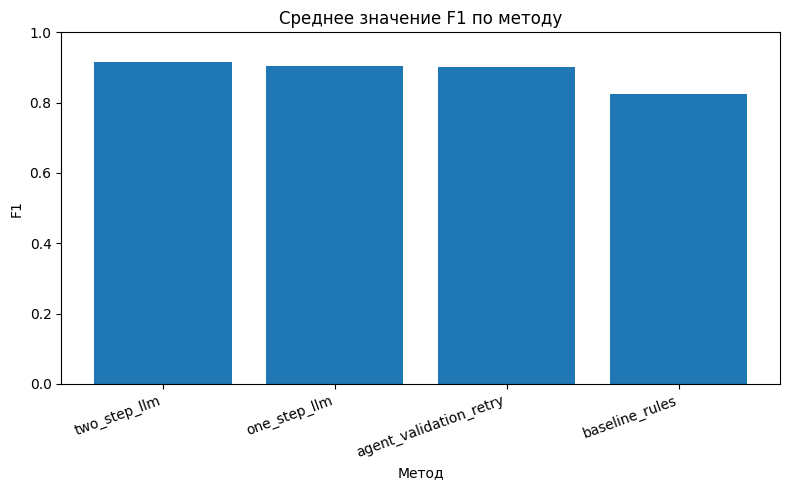

Сохранено: /content/results/fig_f1_by_method.png


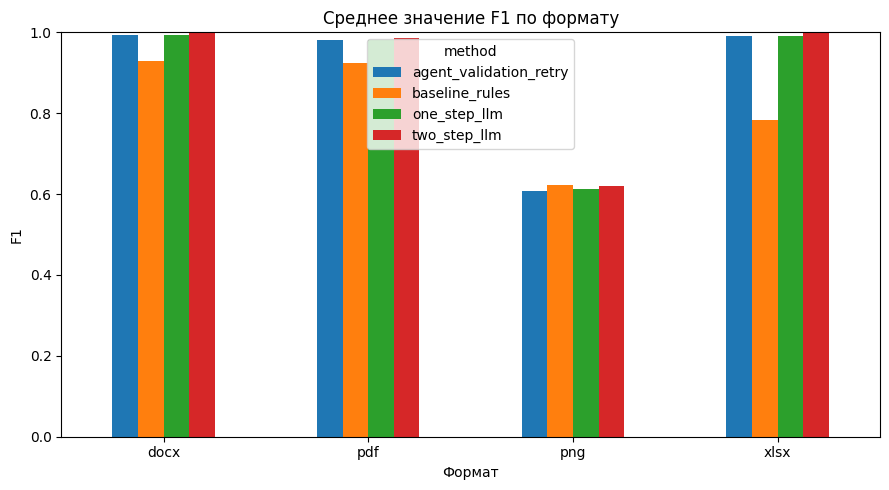

Сохранено: /content/results/fig_f1_by_format.png


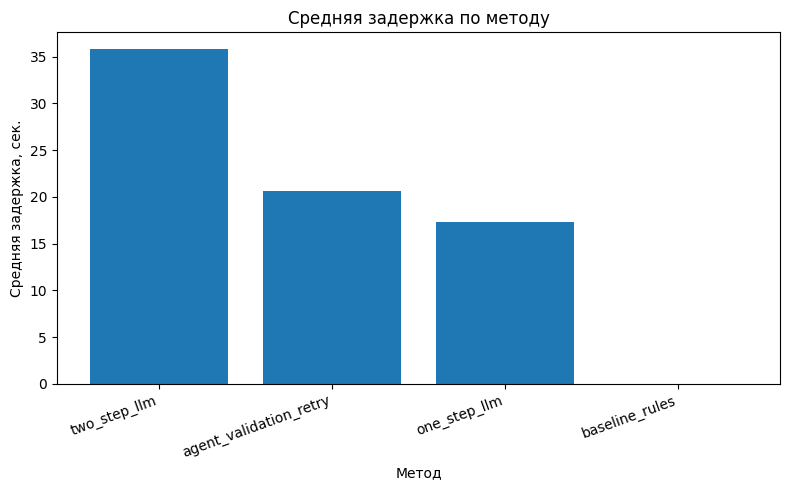

Сохранено: /content/results/fig_latency_by_method.png


In [ ]:
def save_f1_by_method(metrics_by_method: pd.DataFrame):
    df = metrics_by_method.sort_values('f1', ascending=False)
    plt.figure(figsize=(8, 5))
    plt.bar(df['method'], df['f1'])
    plt.ylim(0, 1)
    plt.ylabel('F1')
    plt.xlabel('Метод')
    plt.title('Среднее значение F1 по методу')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    path = RESULTS_DIR / 'fig_f1_by_method.png'
    plt.savefig(path, dpi=200)
    plt.show()
    print('Сохранено:', path)


def save_f1_by_format(metrics_by_method_format: pd.DataFrame):
    pivot = metrics_by_method_format.pivot(index='format', columns='method', values='f1').sort_index()
    ax = pivot.plot(kind='bar', figsize=(9, 5))
    ax.set_ylim(0, 1)
    ax.set_ylabel('F1')
    ax.set_xlabel('Формат')
    ax.set_title('Среднее значение F1 по формату')
    plt.xticks(rotation=0)
    plt.tight_layout()
    path = RESULTS_DIR / 'fig_f1_by_format.png'
    plt.savefig(path, dpi=200)
    plt.show()
    print('Сохранено:', path)


def save_latency_by_method(metrics_by_method: pd.DataFrame):
    df = metrics_by_method.sort_values('avg_latency_sec', ascending=False)
    plt.figure(figsize=(8, 5))
    plt.bar(df['method'], df['avg_latency_sec'])
    plt.ylabel('Средняя задержка, сек.')
    plt.xlabel('Метод')
    plt.title('Средняя задержка по методу')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    path = RESULTS_DIR / 'fig_latency_by_method.png'
    plt.savefig(path, dpi=200)
    plt.show()
    print('Сохранено:', path)


save_f1_by_method(metrics_by_method)
save_f1_by_format(metrics_by_method_format)
save_latency_by_method(metrics_by_method)

## 12. Скачивание результатов из Colab

In [ ]:
# Упаковать results/ и intermediate/texts/ в архив для скачивания.
output_zip = PROJECT_ROOT / 'ie_experiment_outputs.zip'

with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zf:
    for folder in [RESULTS_DIR, TEXTS_DIR]:
        for file in folder.rglob('*'):
            if file.is_file():
                zf.write(file, file.relative_to(PROJECT_ROOT))

print('Архив готов:', output_zip)

# try:
#     from google.colab import files
#     files.download(str(output_zip))
# except Exception as e:
#     print('Автоскачивание доступно только в Colab:', repr(e))

Архив готов: /content/ie_experiment_outputs.zip
